# Predicting Event Interest - Logistic Regression Application

## Step 1: Import Libraries

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import random
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, f1_score, recall_score, 
                             accuracy_score, classification_report, 
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

## Step 2: Load the dataset

This will have been created from the initial data in the 'Predicting Event Interest - Making the Dataset' notebook.

In [18]:
event_data = pd.read_csv('event_attendance_dataset.csv')
print(event_data.head()) # Prints the first 5 rows of the table with all the variables
print(f'Dataset shape: {event_data.shape[0]} rows, {event_data.shape[1]} columns') # Confirms all rows and columns uploaded correctly

   invited  event_hour  event_dow  yes_count  event_train_count   age  \
0        0           8          2        0.0                  2  22.0   
1        0          11          2        0.0                  4  22.0   
2        0          13          4        0.0                187  22.0   
3        0           5          5        0.0                  1  22.0   
4        0           3          5        0.0                 99  22.0   

   is_male  is_en_US  timezone  invite_hour  interested     user       event  
0        1         0     480.0           15           0  3044012  1918771225  
1        1         0     480.0           15           0  3044012  1502284248  
2        1         0     480.0           15           1  3044012  2529072432  
3        1         0     480.0           15           0  3044012  3072478280  
4        1         0     480.0           15           0  3044012  1390707377  
Dataset shape: 15398 rows, 13 columns


## Step 3: Define Features and Target
- X contains the 10 features used to make predictions
- y contains the target variable: interested (1 = yes, 0 = no)
- The data is then split 80/20 into training and test sets

In [20]:
prediction_columns = ['invited', 'event_hour', 'event_dow', 'yes_count', 'event_train_count', 'age', 'is_male', 'is_en_US', 'timezone', 'invite_hour']
X = event_data[prediction_columns] # Use these columns from the dataset
y = event_data['interested'] # This is the target column (the one I'm trying to predict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Train the Model
- A logistic regression classifier is trained on the training set
- class_weight='balanced' is used to account for the class imbalance (73% not interested, 27% interested

In [25]:
model = LogisticRegression(random_state=0, max_iter=1000, class_weight='balanced').fit(X_train, y_train)

## Step 5: Make Predictions
The trained model predicts interested for each row in the withheld test set.

In [26]:
preds = model.predict(X_test) # This outputs the model predictions on the withheld test data

## Step 6: Evaluate the Model

- **Precision**: When the model predicts "interested", how often is it correct?
- **Recall**: Of all the rows that were actually "interested", how many did the model correctly identify?
- **F1 Score**: A combined measure that balances precision and recall

In [31]:
print(classification_report(y_test, preds)) # How well the model performs

              precision    recall  f1-score   support

           0       0.74      0.53      0.62      2224
           1       0.29      0.51      0.37       856

    accuracy                           0.52      3080
   macro avg       0.52      0.52      0.49      3080
weighted avg       0.61      0.52      0.55      3080



## Step 7: Interpret the Coefficients
Each feature is assigned a coefficient: positive values push the prediction towards interested, negative values push away from interested.

In [30]:
# Creating a new table with two columns - to see which variables drive the predictions
# This will help us easily read the data
coefficients = pd.DataFrame({ 
    'feature': prediction_columns,
    'coefficient': model.coef_[0]
})
print(coefficients.sort_values('coefficient', ascending=False)) # Sorts the table in order of weights

             feature  coefficient
6            is_male     0.092919
2          event_dow     0.053264
4  event_train_count     0.002068
3          yes_count     0.000527
8           timezone     0.000076
1         event_hour    -0.003030
5                age    -0.005670
9        invite_hour    -0.008297
7           is_en_US    -0.113067
0            invited    -0.341972


## Step 8: Visualise the results

To aid understanding, the results have been visualised using three methods:

- bar chart of classification metrics
- confusion matrix heatmap
- effect of coefficients on target variable (interested)

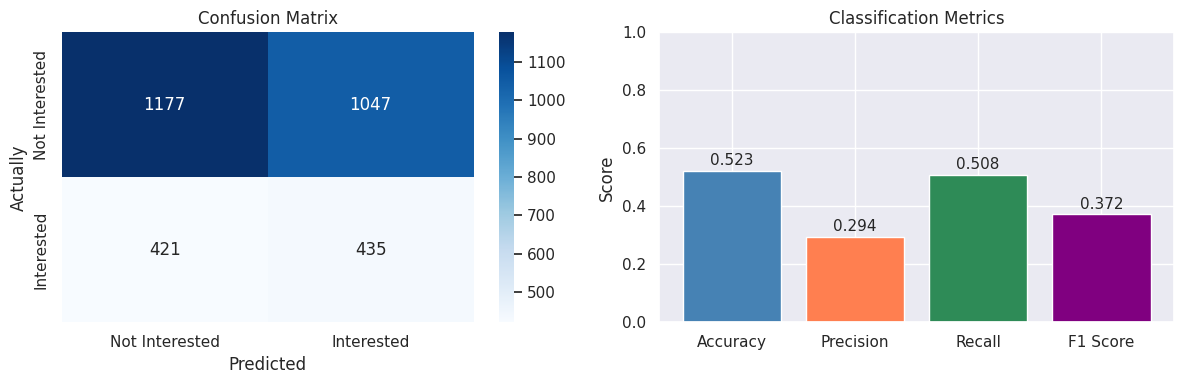

In [34]:
# Create a bar chart and confusion matrix heatmap to visualise results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Not Interested', 'Interested'],
           yticklabels=['Not Interested', 'Interested'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actually')
axes[0].set_title('Confusion Matrix')

# Metrics bar chart
metrics = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds),
    'Recall': recall_score(y_test, preds),
    'F1 Score': f1_score(y_test, preds)
}

bars = axes[1].bar(metrics.keys(), metrics.values(), 
                  color=['steelblue', 'coral', 'seagreen', 'purple'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

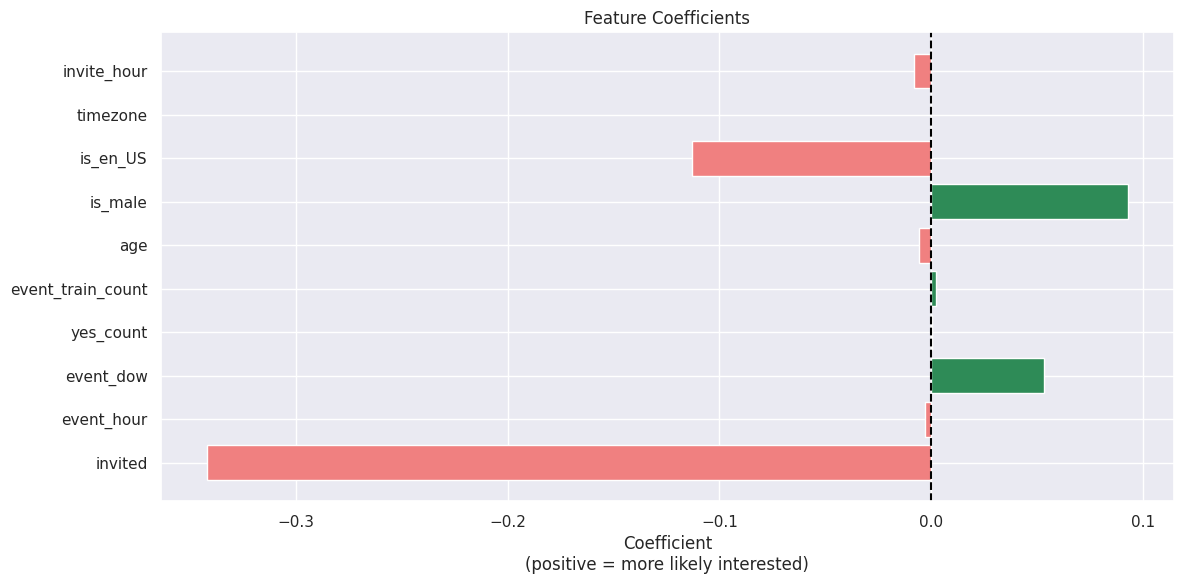

In [44]:
# Visualise feature coefficients
colors = ['seagreen' if c > 0 else 'lightcoral' for c in coefficients['coefficient']]
plt.figure(figsize=(12, 6))
plt.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
plt.xlabel('Coefficient\n(positive = more likely interested)')
plt.title('Feature Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()